# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

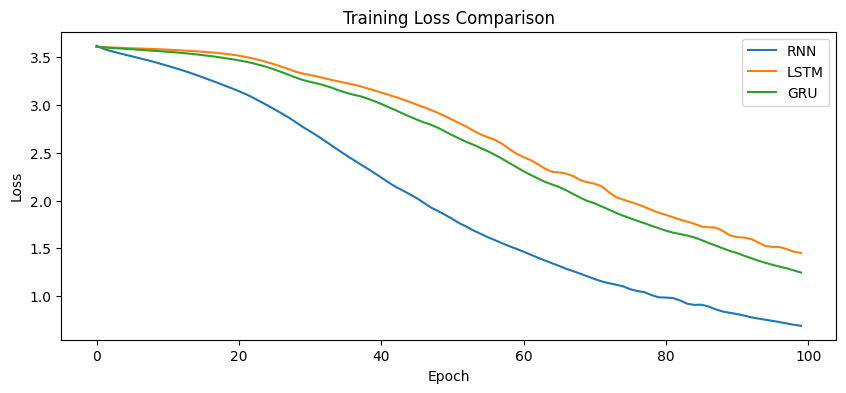

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models transforming artificial intelligence sentences
LSTM: deep learning models models generate meaningful sentences
GRU : deep learning models can generate meaningful sentences


# 📊 Model Performance Comparison

The three models were trained on the **same corpus**, with the same embedding size,
number of recurrent units, optimizer, loss function, and number of epochs.

This makes the comparison more meaningful because the main difference is the
recurrent architecture itself.

In [12]:
# Collect final training metrics and model sizes

results = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Final Training Loss": [
        rnn_history.history["loss"][-1],
        lstm_history.history["loss"][-1],
        gru_history.history["loss"][-1]
    ],
    "Final Training Accuracy": [
        rnn_history.history["accuracy"][-1],
        lstm_history.history["accuracy"][-1],
        gru_history.history["accuracy"][-1]
    ],
    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ]
})

results["Training Accuracy (%)"] = results["Final Training Accuracy"] * 100
results = results.drop(columns=["Final Training Accuracy"])

results

,Model,Final Training Loss,Parameters,Training Accuracy (%)
0,Vanilla RNN,0.690137,9797,91.428572
1,LSTM,1.452620,28421,74.285716
2,GRU,1.246346,22405,77.142859


## 🔢 Parameter Comparison

The number of trainable parameters helps explain the architectural difference.

- Vanilla RNN has the simplest recurrent computation.
- LSTM has more parameters because it uses multiple gates and a cell state.
- GRU has fewer parameters than LSTM because its gating mechanism is simpler.

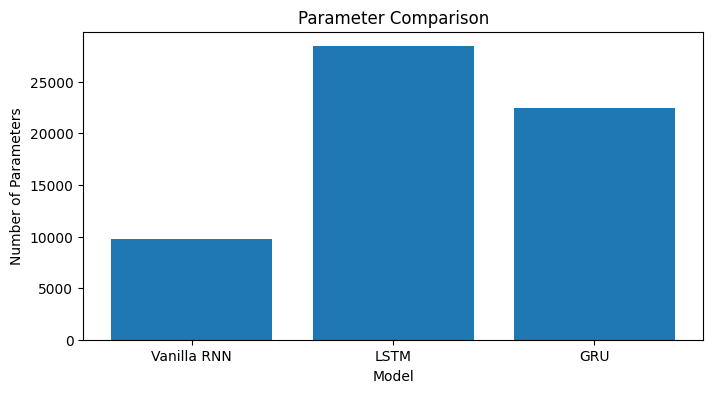

In [13]:
# Visual comparison of trainable parameters

plt.figure(figsize=(8, 4))
plt.bar(results["Model"], results["Parameters"])
plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title("Parameter Comparison")
plt.show()

# 🧪 Generate Multiple Text Samples

A single generated sentence is not enough to compare the models.
We therefore test all three models with multiple seed phrases from the corpus.

Because this is a **very small learning corpus**, the models can memorize
frequent patterns. The purpose here is to demonstrate the mechanics of
next-word prediction and compare the architectures rather than to build a
production-quality language model.

In [14]:
seed_texts = [
    "deep learning",
    "recurrent neural networks",
    "text generation models",
    "lstm helps"
]

for seed in seed_texts:
    print("\n" + "=" * 70)
    print("SEED:", seed)
    print("=" * 70)
    print("RNN :", generate_text(rnn_model, seed, 6))
    print("LSTM:", generate_text(lstm_model, seed, 6))
    print("GRU :", generate_text(gru_model, seed, 6))


SEED: deep learning
RNN : deep learning models transforming artificial intelligence sentences artificial
LSTM: deep learning models models generate meaningful sentences sentences
GRU : deep learning models can generate meaningful sentences sentences

SEED: recurrent neural networks
RNN : recurrent neural networks are useful for sequential data data
LSTM: recurrent neural networks are useful for sequential data data
GRU : recurrent neural networks are useful for data data data

SEED: text generation models
RNN : text generation models predict the next word data for
LSTM: text generation models predict the next sentences sentences sentences
GRU : text generation models can meaningful sentences sentences sentences sentences

SEED: lstm helps
RNN : lstm helps remember long term dependencies the next
LSTM: lstm helps remember long term dependencies dependencies data
GRU : lstm helps remember long term dependencies dependencies for


# 🔍 Detailed Performance Analysis

### Vanilla RNN

The Vanilla RNN acts as the baseline model. It can learn short sequential
relationships because the hidden state carries information from previous
time steps. However, standard RNNs can struggle with long-term dependencies
because of the vanishing-gradient problem.

### LSTM

LSTM introduces a cell state and three major gates: **forget, input, and
output gates**. These mechanisms allow the network to selectively retain,
update, and expose information. This makes LSTM better suited to sequences
where information from earlier time steps remains important.

### GRU

GRU uses **update and reset gates** and does not maintain a separate cell
state. Its architecture is simpler than LSTM, so it generally has fewer
parameters while still being capable of learning useful dependencies.

### Important observation for this notebook

This corpus contains only a few short sentences. Therefore, it is too small
to make a strong real-world claim that one architecture is universally
better than another. The main objective is to understand how the three
architectures learn and generate text under the same experimental setup.

The generated text should be evaluated qualitatively for:

- grammatical flow
- sensible word transitions
- repetition
- ability to continue the seed phrase
- consistency with the training corpus

# 🏁 Final Comparison

| Aspect | Vanilla RNN | LSTM | GRU |
|---|---|---|---|
| Architecture complexity | Low | High | Medium |
| Gates | None | Forget, Input, Output | Update, Reset |
| Separate cell state | No | Yes | No |
| Long-term dependency handling | Weak | Strong | Strong |
| Parameters | Lowest | Highest | Lower than LSTM |
| Training efficiency | High | Lower | Often higher than LSTM |
| Suitable role in this assignment | Baseline | Long-term dependency model | Efficient gated alternative |

The exact loss and accuracy values should be taken from the output of the
notebook after running it.

# 🎯 Assignment Conclusion

This project implemented a word-level text generation system using three
recurrent architectures: **Vanilla RNN, LSTM, and GRU**.

The text corpus was tokenized into integer word IDs, and n-gram-style
sequences were created for next-word prediction. Each model used an embedding
layer followed by its respective recurrent layer and a softmax output layer.

The models were trained under the same experimental conditions and compared
using training loss, training accuracy, parameter count, and generated text.

The Vanilla RNN provides a simple baseline but is limited when long-term
dependencies are important. LSTM improves memory handling through its cell
state and three gates. GRU provides a simpler gated architecture using update
and reset gates, often providing a useful balance between model complexity
and sequence-learning ability.

The experiment demonstrates the progression from a basic recurrent model to
gated recurrent architectures and shows why LSTM and GRU are commonly used
when sequential context needs to be preserved.

# 🎓 Viva Questions

1. **Why did we use word-level tokenization?**  
   To convert the text corpus into numerical word IDs so that the neural
   networks can learn next-word relationships.

2. **What is the target variable in this assignment?**  
   The target is the next word in a sequence.

3. **Why is the input sequence padded?**  
   Padding makes all training sequences have the same length so they can be
   processed together in batches.

4. **Why do we use a softmax activation in the output layer?**  
   Because the model must produce a probability distribution over all words
   in the vocabulary.

5. **Why can Vanilla RNN forget older information?**  
   Repeated gradient multiplication during BPTT can cause vanishing gradients,
   making it difficult to learn long-term dependencies.

6. **What makes LSTM different from RNN?**  
   LSTM uses a cell state and gates to control which information is forgotten,
   added, and exposed.

7. **Why is GRU generally simpler than LSTM?**  
   GRU combines its memory-control mechanism into fewer gates and does not
   maintain a separate cell state.

8. **Why are all three models trained on the same corpus?**  
   To make the architectural comparison fair.

9. **Why might the generated text repeat training phrases?**  
   The corpus is extremely small, so the models can memorize patterns instead
   of learning a broad language distribution.

10. **How could this project be improved?**  
    A much larger corpus, more training data, validation data, regularization,
    better sampling, and a larger vocabulary/model could be used.

# 📌 Final Assignment Notes

### What was implemented

- A small text corpus was prepared for next-word prediction.
- The corpus was tokenized and converted into padded input sequences.
- Three recurrent architectures were trained on exactly the same data:
  - Vanilla RNN
  - LSTM
  - GRU
- Training loss and accuracy were recorded for comparison.
- Generated text was produced from the trained models.
- Parameter count and generated outputs were compared.

### Important interpretation

Because the supplied corpus is intentionally very small, the models can memorize parts of the training text. Therefore, the generated sentences demonstrate the mechanics of text generation but should not be interpreted as evidence of production-level language understanding.

The actual loss, accuracy and generated text shown in this notebook should be taken from the cells after running the notebook in Google Colab.


# ✅ Submission Checklist

- [ ] Run all cells from top to bottom in Google Colab.
- [ ] Confirm that RNN, LSTM and GRU training complete without errors.
- [ ] Keep the training-loss comparison graph.
- [ ] Keep the generated-text outputs for all three models.
- [ ] Keep the model comparison and parameter comparison tables.
- [ ] Review the conclusion after seeing the actual outputs.
- [ ] Download the executed `.ipynb` from Colab for submission.
